# Regression Models
To predict corn returns at time t+1

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("enriched_corn_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,corn_close,corn_volume,corn_ret,corn_volume_roll_z,corn_rv_5d,corn_rv_20d,month,atr_14,sma_spread,"macd_(12,26,9)",...,d(yc_2_3m),d(yc_curvature),d(T10_yield),d(T2_yield),prod_w_temp,prod_w_tmin,prod_w_tmax,prod_w_prcp,prod_w_rhum,prod_w_wspd
Date,,,,,,,,,,,,,,,,,,,,,
2000-10-02,192.00,3.0,0.000000,-0.534580,0.021779,0.053082,10.0,2.107143,0.028748,2.094062,...,NaN,NaN,NaN,NaN,15.064828,10.321314,19.777591,0.000000,48.411058,9.724337
2000-10-03,195.25,3.0,0.016927,-0.484432,0.018853,0.055290,10.0,1.857143,0.031072,2.314839,...,5.000000e-02,-0.02,0.04,0.02,13.709217,8.389750,19.058552,1.036692,51.591682,11.692289
2000-10-04,199.50,3.0,0.021767,-0.520727,0.028676,0.059405,10.0,1.964286,0.036285,2.608881,...,3.000000e-02,0.06,0.03,0.03,10.763256,7.729175,13.741328,5.597392,60.499126,13.658984
2000-10-05,200.50,3.0,0.005013,-0.520727,0.029111,0.057702,10.0,2.535714,0.043004,2.943438,...,-2.000000e-02,0.00,-0.03,-0.01,7.176648,4.210126,9.872261,12.300664,67.352749,12.139667
2000-10-06,199.50,3.0,-0.004988,-0.520727,0.028466,0.050595,10.0,2.785714,0.045840,3.263189,...,-3.000000e-02,0.01,-0.05,-0.04,3.198147,-0.591903,6.773106,0.000000,47.716438,13.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02,452.25,0.0,-0.004403,-2.807366,0.019868,0.050363,4.0,10.178571,0.001921,6.818618,...,-2.000000e-02,-0.02,-0.02,-0.02,5.324497,2.659980,8.495854,0.490944,51.256284,10.833227
2026-04-06,454.00,126749.0,0.003870,0.403609,0.017178,0.048951,4.0,9.625000,-0.002358,6.369381,...,3.000000e-02,0.00,0.03,0.05,2.606314,0.251393,5.050398,0.000000,30.310008,9.399977
2026-04-07,449.00,172653.0,-0.011013,0.429768,0.015276,0.045451,4.0,9.410714,-0.006572,5.821673,...,-2.000000e-02,-0.02,-0.01,-0.03,2.799057,0.970725,4.823383,0.000000,17.532417,5.801164


We tune all models using 10-split time-series cross-validation on the training sample to preserve chronological ordering and avoid look-ahead bias, then evaluate the selected models on a final holdout test period. The final holdout test period gives us an unbiased approximation of test error which cross-validation cannot since we tune hyperparameters using CV so we cherry-pick models with the lowest CV error and hence it is biased downwards.

In [16]:
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month',
    'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]
response_col = 'corn_ret_t+1'
model_df = df[feature_cols + [response_col]].copy()
if "date" in df.columns:
    model_df = df[["date"] + feature_cols + [response_col]].copy()
    model_df["date"] = pd.to_datetime(model_df["date"])
    model_df = model_df.sort_values("date")
else:
    model_df = model_df.sort_index()
model_df = model_df.dropna(subset=[response_col])

# Final clean feature and response data
X = model_df[feature_cols]
y = model_df[response_col]

# 80-20 Train-Test split for unbiased holdout test period
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Month is a categorical variable
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]
# Setting up feature preprocessing pipelines
preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # to fill NaN values
        ("scaler", StandardScaler())        # Scaling needed for Lasso, etc. except for Regression Trees & Random Forests
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),   # to fill NaN values
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])
preprocessor_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),    # Scaling not needed here
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

We perform a special type of CV called Time-Series CV which does not shuffle the folds unlike standard K-fold CV to preserve the chronological order of the data and to avoid look-ahead bias caused by future folds being used in the shuffled training set.

In [17]:
# 10-fold Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=10)

# Helper to calculate RMSE for CV
def cv_rmse(model, X, y, cv):
    rmses = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)
    return np.mean(rmses)

# Helper to calculate RMSE, MAE, and R^2 for final holdout test period
def evaluate_holdout(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_r2": r2_score(y_test, preds)
    }

**Multilear Regression**

--- Multiple Linear Regression Results ---
Avg 10-Fold CV RMSE: 0.019246
Holdout Test RMSE:   0.017771
Holdout Test R2:     -0.016767


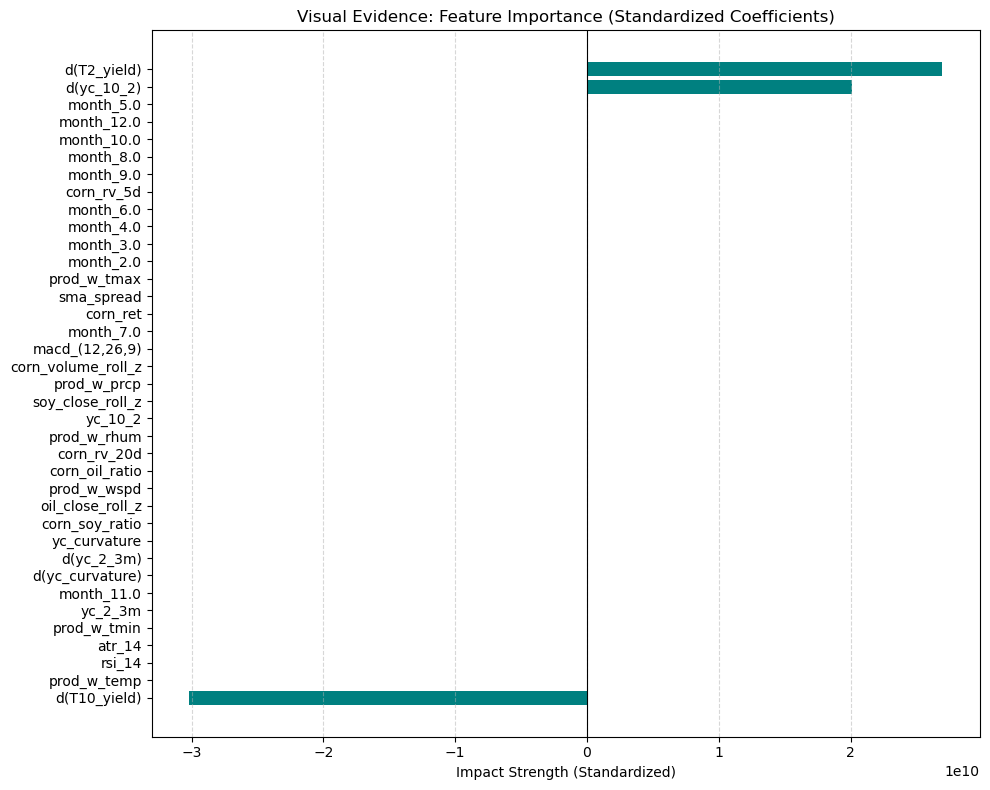

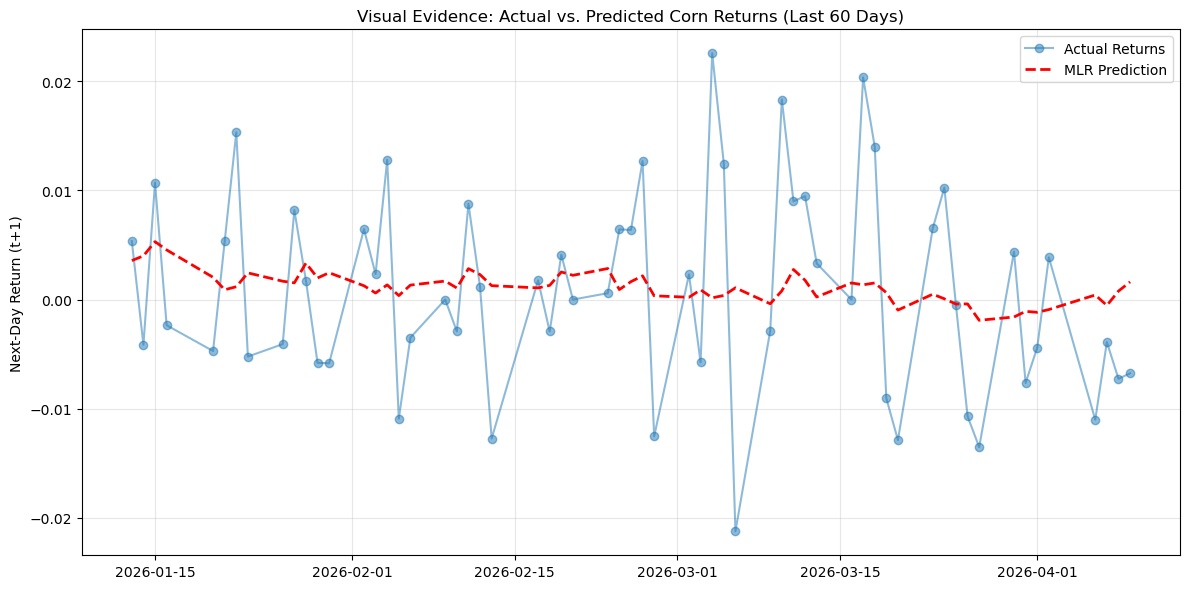

In [18]:
from sklearn.linear_model import LinearRegression

# 1. Setup and Fit the MLR Pipeline
mlr_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

# 2. Performance Results (CV and Holdout)
avg_cv_rmse = cv_rmse(mlr_model, X_train, y_train, tscv)
mlr_results = evaluate_holdout("Multiple Linear Regression", mlr_model, X_train, y_train, X_test, y_test)

print(f"--- Multiple Linear Regression Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

# 3. PLOT 1: Standardized Coefficients (Feature Importance)
# Fit once on the full training set to extract coefficients
mlr_model.fit(X_train, y_train)

# Get feature names after One-Hot Encoding
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

# Create and sort a DataFrame for plotting
coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='teal')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Visual Evidence: Feature Importance (Standardized Coefficients)')
plt.xlabel('Impact Strength (Standardized)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. PLOT 2: Actual vs. Predicted (Visualizing Accuracy)
# Generate predictions for the holdout test set
test_preds = mlr_model.predict(X_test)

plt.figure(figsize=(12, 6))
# Plotting only the last 60 days of the holdout for better clarity
plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Returns', marker='o', alpha=0.5)
plt.plot(y_test.index[-60:], test_preds[-60:], label='MLR Prediction', linestyle='--', color='red', linewidth=2)
plt.title('Visual Evidence: Actual vs. Predicted Corn Returns (Last 60 Days)')
plt.ylabel('Next-Day Return (t+1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Our initial Multiple Linear Regression failed to provide predictive power, resulting in a negative $R^2$. The model is currently suffering from numerical instability caused by redundant features.As shown in the standardized coefficients plot, variables like yc_10_2 and d(yc_10_2) are highly collinear, causing the weights to inflate artificially. To fix this, we are refining our feature selection by removing redundant 'level' variables and keeping only the 'change' (d()) metrics. This will reduce noise, eliminate the multicollinearity seen in the yield curve data, and allow the model to actually learn from the underlying trends.

--- Updated MLR Results ---
Avg 10-Fold CV RMSE: 0.019150
Holdout Test RMSE:   0.017761
Holdout Test R2:     -0.015545


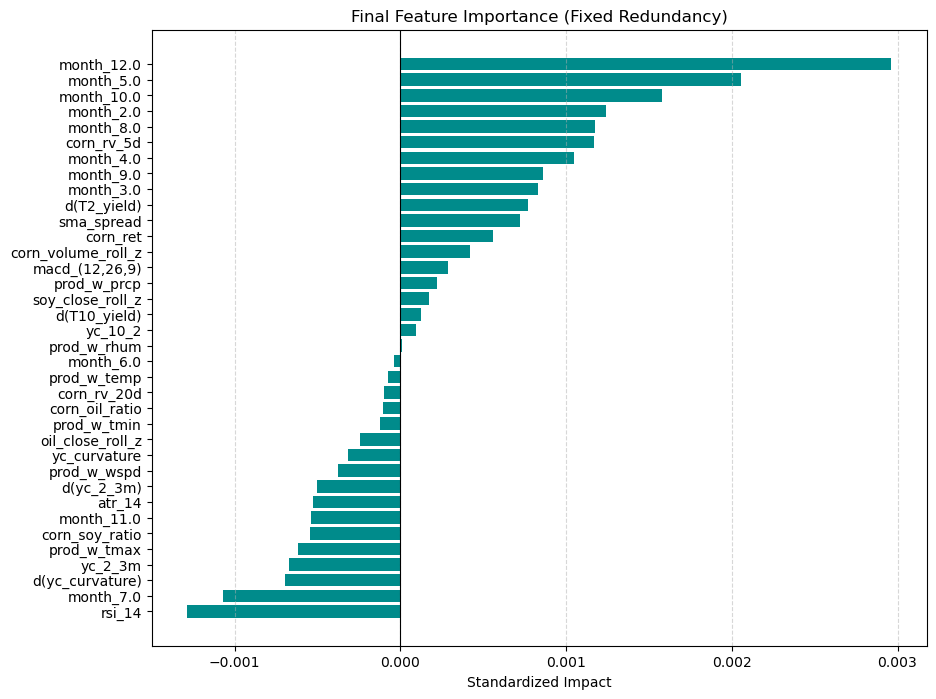

In [9]:
from sklearn.linear_model import LinearRegression

# 1. Update your feature list (Removed 'd(yc_10_2)')
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]

# 2. Re-define column groups for the preprocessor
categorical_cols = ["month"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# 3. RE-CREATE the preprocessor to exclude the missing column
preprocessor_scaled_updated = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_cols)
])

# 4. Prepare data for the model
X_train_clean = X_train[feature_cols]
X_test_clean = X_test[feature_cols]

# 5. Define and Fit the MLR Pipeline
mlr_model = Pipeline([
    ("preprocessor", preprocessor_scaled_updated),
    ("regressor", LinearRegression())
])

# 6. Performance Results
avg_cv_rmse = cv_rmse(mlr_model, X_train_clean, y_train, tscv)
mlr_results = evaluate_holdout("Multiple Linear Regression", mlr_model, X_train_clean, y_train, X_test_clean, y_test)

print(f"--- Updated MLR Results ---")
print(f"Avg 10-Fold CV RMSE: {avg_cv_rmse:.6f}")
print(f"Holdout Test RMSE:   {mlr_results['test_rmse']:.6f}")
print(f"Holdout Test R2:     {mlr_results['test_r2']:.6f}")

# 7. Visualization: Feature Importance
mlr_model.fit(X_train_clean, y_train)
ohe = mlr_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feature_names = numeric_cols + ohe.get_feature_names_out(categorical_cols).tolist()
coeffs = mlr_model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs}).sort_values(by='Weight')

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='darkcyan')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Final Feature Importance (Fixed Redundancy)')
plt.xlabel('Standardized Impact')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()